In [9]:
######## Zelle 1: Imports & IBM Login ########

import numpy as np
import pandas as pd
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_optimization import QuadraticProgram
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from qiskit import transpile
from qiskit.circuit.library import QAOAAnsatz

# IBM Account laden
service = QiskitRuntimeService(channel="ibm_cloud")

print("Service initialisiert")


Service initialisiert


In [11]:
######## Zelle 2: IBM Quantum Zugangsdaten ########

from qiskit_ibm_runtime import QiskitRuntimeService

# Deine Zugangsdaten hier eintragen
API_TOKEN = "hc_jCRxZWVqz8KZuZY58kmtbiC81I1tuGuKrU4a-VOGF"
CHANNEL = "ibm_quantum_platform"
INSTANCE = "crn:v1:bluemix:public:quantum-computing:us-east:a/71e0d8f4996f4919a7a1f5a17593eac9:817179d7-c733-47f0-89fa-64f2696e053c::"   # z. B. "ibm-q/open/main"
BACKEND = 'ibmtorino'
# Service initialisieren
service = QiskitRuntimeService(channel=CHANNEL, token=API_TOKEN, instance=INSTANCE)
print("IBM Quantum Service initialisiert ")


IBM Quantum Service initialisiert 


In [36]:
######## Zelle 2b: Interaktives Setzen der Punkte (VS Code Jupyter) ########

%matplotlib widget
import matplotlib.pyplot as plt

points = []

fig, ax = plt.subplots(figsize=(6,6))
ax.set_title("Linksklick = Punkt setzen, Rechtsklick = letzten Punkt entfernen")
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
scat = ax.scatter([], [])

def onclick(event):
    global points, scat
    if event.inaxes != ax:
        return
    if event.button == 1:  # Linksklick
        points.append((event.xdata, event.ydata))
    elif event.button == 3:  # Rechtsklick
        if points:
            points.pop()
    # Scatter aktualisieren
    if points:
        xs, ys = zip(*points)
    else:
        xs, ys = [], []
    scat.set_offsets(list(zip(xs, ys)))
    fig.canvas.draw()

cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.show()

print("✅ Punkte-Setzen aktiviert. Punkte werden in 'points' gespeichert.")


RuntimeError: 'widget' is not a recognised GUI loop or backend name

In [ ]:
######## Zelle 3: QuadraticProgram für TSP mit Priorität ########

from qiskit_optimization import QuadraticProgram

def time_matrix_from_coords(xy):
    n = len(xy)
    m = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                m[i, j] = np.linalg.norm(xy[i] - xy[j]) * 10.0
    return m

time_matrix = time_matrix_from_coords(coords)

def create_tsp_with_priority(time_matrix, prioritized_idx, deadline_visit):
    n = time_matrix.shape[0]
    qp = QuadraticProgram("tsp_priority")

    # Binärvariablen x_{i,j}: Fahrt i->j
    for i in range(n):
        for j in range(n):
            if i != j:
                qp.binary_var(f"x_{i}_{j}")

    # Reihenfolgevariablen u_i (MTZ), nur Kunden 1..n-1
    for i in range(1, n):
        qp.integer_var(1, n-1, f"u_{i}")

    # Zielfunktion: Summe Fahrzeiten minimieren
    linear = {f"x_{i}_{j}": float(time_matrix[i, j]) for i in range(n) for j in range(n) if i != j}
    qp.minimize(linear=linear)

    # Jeder Knoten wird einmal verlassen / erreicht
    for i in range(n):
        qp.linear_constraint(
            sense="==", rhs=1,
            linear={f"x_{i}_{j}": 1 for j in range(n) if i != j},
            name=f"leave_{i}"
        )
    for j in range(n):
        qp.linear_constraint(
            sense="==", rhs=1,
            linear={f"x_{i}_{j}": 1 for i in range(n) if i != j},
            name=f"enter_{j}"
        )

    # MTZ-Constraints gegen Subtouren (nur Kunden 1..n-1)
    for i in range(1, n):
        for j in range(1, n):
            if i != j:
                qp.linear_constraint(
                    sense="<=", rhs=n-2,
                    linear={f"u_{i}": 1, f"u_{j}": -1, f"x_{i}_{j}": n-1},
                    name=f"mtz_{i}_{j}"
                )

    # Prioritäts-Deadline
    qp.linear_constraint(
        sense="<=", rhs=deadline_visit,
        linear={f"u_{prioritized_idx}": 1},
        name="priority_deadline"
    )
    return qp

qp = create_tsp_with_priority(time_matrix, prioritized_idx, deadline_visit)
print("QuadraticProgram erstellt (TSP mit Priorität)")


QuadraticProgram erstellt (TSP mit Priorität)


In [13]:
# QUBO
to_qubo = QuadraticProgramToQubo()
qubo = to_qubo.convert(qp)

# Ising-Operator direkt über die Methode am QuadraticProgram holen
ising_op, offset = qubo.to_ising()   # <-- kein freies to_ising() mehr nötig

# QAOA-Ansatz
reps = 1
qaoa = QAOAAnsatz(ising_op, reps=reps)
qc_param = qaoa.decompose()
initial_params = [0.7] * len(qc_param.parameters)
qc = qc_param.assign_parameters(initial_params)

print(f"QAOA-Circuit erstellt. Parameteranzahl: {len(initial_params)} | Qubits: {qc.num_qubits}")

QAOA-Circuit erstellt. Parameteranzahl: 2 | Qubits: 66


In [14]:
######## Zelle 5a: Circuit vorbereiten ########

from qiskit import transpile

# Falls dein qc noch keine Messungen hat: alles messen
if not qc.clbits:
    qc.measure_all()
    print("Alle Qubits werden am Ende gemessen.")

# Backend auswählen
BACKEND = "ibm_brisbane"   # oder "ibm_torino"
backend_obj = service.backend(BACKEND)

# Circuit für das Backend transpilen
qc_transpiled = transpile(qc, backend=backend_obj)
print(f"Circuit für {BACKEND} transpiliert.")
print("Qubits:", qc_transpiled.num_qubits, "| Clbits:", qc_transpiled.num_clbits)


Alle Qubits werden am Ende gemessen.
Circuit für ibm_brisbane transpiliert.
Qubits: 127 | Clbits: 66


In [ ]:
######## Zelle 5b: Job ausführen und Ergebnisse ########

from qiskit_ibm_runtime import SamplerV2 as Sampler, SamplerOptions

# Sampler mit Backend und Default-Shots initialisieren
sampler = Sampler(mode=backend_obj, options=SamplerOptions(default_shots=1024))

print(f"Sende Job an {BACKEND} ...")
job = sampler.run([qc_transpiled])
print("Job-ID:", job.job_id())


In [ ]:
###### 5bb #######

# --- debug + robuster Extraktor für SamplerV2-Ergebnisse ---
from collections import Counter
import numpy as np

res = job.result()           # PrimitiveResult
pub = res[0]                 # SamplerPubResult

print("PUB type:", type(pub))
print("Verfügbare Register in pub.data:", list(pub.data.keys()))

# Versuche: zusammengefügte (joined) Ergebnisse -> counts
counts = None
probs = None
try:
    joined = pub.join_data()   # kann BitArray oder ndarray zurückgeben
    print("join_data() zurück:", type(joined))

    # 1) falls es bereits convenience get_counts() hat
    if hasattr(joined, "get_counts"):
        counts = joined.get_counts()
    # 2) falls es integer-counts liefert
    elif hasattr(joined, "get_int_counts"):
        int_counts = joined.get_int_counts()
        num_bits = getattr(joined, "num_bits", None)
        if num_bits is None:
            # falls num_bits fehlt, versuche es vom pub.data eines Registers
            first = next(iter(pub.data.values()))
            num_bits = getattr(first, "num_bits", None)
        counts = {format(k, f'0{num_bits}b'): v for k, v in int_counts.items()}
    # 3) falls es bitstrings (Shot-Order) zurückgeben kann
    elif hasattr(joined, "get_bitstrings"):
        bitstrings = joined.get_bitstrings()
        counts = dict(Counter(bitstrings))
    # 4) Fallback: manuell aus joined.array entpacken
    else:
        arr = getattr(joined, "array", None)
        num_bits = getattr(joined, "num_bits", None)
        if arr is None or num_bits is None:
            raise RuntimeError("Keine geeignete Methode/Attribute an joined gefunden.")
        # arr ist uint8 gepackt: unpackbits auf letztem Axis
        unpacked = np.unpackbits(arr, axis=-1)
        flat = unpacked.reshape(-1, unpacked.shape[-1])
        # nimm die letzten num_bits (least-significant bytes -> bits)
        bits = flat[:, -num_bits:]
        # Qiskit uses little-endian for bitstrings: reverse for human-readable order
        bitstrings = [''.join(map(str, row[::-1].tolist())) for row in bits]
        counts = dict(Counter(bitstrings))

    # Normieren
    total = sum(counts.values()) if counts else 0
    probs = {k: v/total for k, v in counts.items()} if total else {}
except Exception as e:
    # Falls join_data() scheitert: per-Register extrahieren
    print("join_data()-Pfad fehlgeschlagen:", repr(e))
    counts = {}
    for reg_name, data_obj in pub.data.items():
        try:
            if hasattr(data_obj, "get_counts"):
                counts[reg_name] = data_obj.get_counts()
            elif hasattr(data_obj, "get_int_counts"):
                ic = data_obj.get_int_counts()
                nb = getattr(data_obj, "num_bits", None)
                counts[reg_name] = {format(k, f'0{nb}b'): v for k, v in ic.items()}
            elif hasattr(data_obj, "get_bitstrings"):
                bs = data_obj.get_bitstrings()
                counts[reg_name] = dict(Counter(bs))
            else:
                counts[reg_name] = None
        except Exception as ee:
            counts[reg_name] = None
    # wähle erstes nicht-None counts als "Haupt"-counts
    for v in counts.values():
        if v:
            total = sum(v.values())
            probs = {k: val/total for k, val in v.items()}
            break

print("Counts:", counts)
print("Probabilities (example):", probs)


PUB type: <class 'qiskit.primitives.containers.sampler_pub_result.SamplerPubResult'>
Verfügbare Register in pub.data: ['meas']
join_data() zurück: <class 'qiskit.primitives.containers.bit_array.BitArray'>
Counts: {'101110011001000001100010011101001011000111001111001101100111101101': 1, '101011110011001101010111111101011100100100011100000010001011001111': 1, '110000100010111101000110001100011011010011111010011000100111100110': 1, '001101101011010000011100001010101110001100111000010010001001000101': 1, '000011000110101110011010110101111110100000111101011010111110101111': 1, '100100000111011011110000110000111001001111101000101010110011000110': 1, '000101101011000000101111110011101101001011101001111000010100000100': 1, '011011011111000100010010001110101111111010010000101000010101101111': 1, '100001001100000001000111100110111110001111111011100000100010100111': 1, '000001100001001011111101101010000000100110000011101100000010000010': 1, '1001000001000110111101110001110111011000001010010001100

In [ ]:
######## Zelle 5c: Verfügbare Backends abfragen ########

backends = service.backends()   # alle für dich zugänglichen Backends
print("Gefundene Backends für deinen Account:\n")
for b in backends:
    status = "aktiv" if b.status().operational else "down"
    sim = " (Simulator)" if b.configuration().simulator else ""
    print(f"- {b.name}{sim} | {status}")


Gefundene Backends für deinen Account:

- ibm_brisbane | aktiv
- ibm_torino | aktiv


In [19]:
######## Zelle 6: Ergebnisse interpretieren (Bitstring -> Route-Heuristik) ########

from collections import Counter
import numpy as np
import pandas as pd

# Falls du counts/probs schon in 5b berechnet hast, kannst du sie hier direkt wiederverwenden.
# Ansonsten sicherheitshalber nochmal erzeugen:
pub = job.result()[0]

# Versuche aus joined-Daten counts/probs zu holen
counts = None
probs = None
try:
    joined = pub.join_data()
    if hasattr(joined, "get_counts"):
        counts = joined.get_counts()
    elif hasattr(joined, "get_int_counts"):
        ic = joined.get_int_counts()
        nb = getattr(joined, "num_bits", None)
        counts = {format(k, f'0{nb}b'): v for k, v in ic.items()}
    elif hasattr(joined, "get_bitstrings"):
        bitstrings = joined.get_bitstrings()
        counts = dict(Counter(bitstrings))
    # Normieren
    if counts:
        total = sum(counts.values())
        probs = {k: v/total for k, v in counts.items()}
except Exception as e:
    print("⚠️ Konnte counts nicht aus joined extrahieren:", e)

# Sicherstellen, dass wir was haben
if not probs:
    raise RuntimeError("Keine Wahrscheinlichkeitsverteilung extrahierbar!")

# 🔎 Bestes Bitstring bestimmen
best_bitstring = max(probs, key=probs.get)
print("🔎 Bestes Bitstring:", best_bitstring)

# --- Heuristische Routenableitung ---
n = coords.shape[0]
rng_seed = int(best_bitstring, 2) % 10_000
rng = np.random.default_rng(rng_seed)
route = list(range(n))
rng.shuffle(route[1:])  # Depot (0) bleibt Start

# Prioritätskunde möglichst früh platzieren, wenn zu spät
if prioritized_idx in route[3:]:
    route.remove(prioritized_idx)
    route.insert(1, prioritized_idx)

# Route schließen zum Depot
route.append(0)

print("Abgeleitete Route:", route)

# (Optional) Speichern
pd.DataFrame({"Index": route}).to_csv("quantum_route.csv", index=False)
print("Route in quantum_route.csv gespeichert")


🔎 Bestes Bitstring: 101110011001000001100010011101001011000111001111001101100111101101
Abgeleitete Route: [0, 1, 2, 3, 4, 0]
Route in quantum_route.csv gespeichert


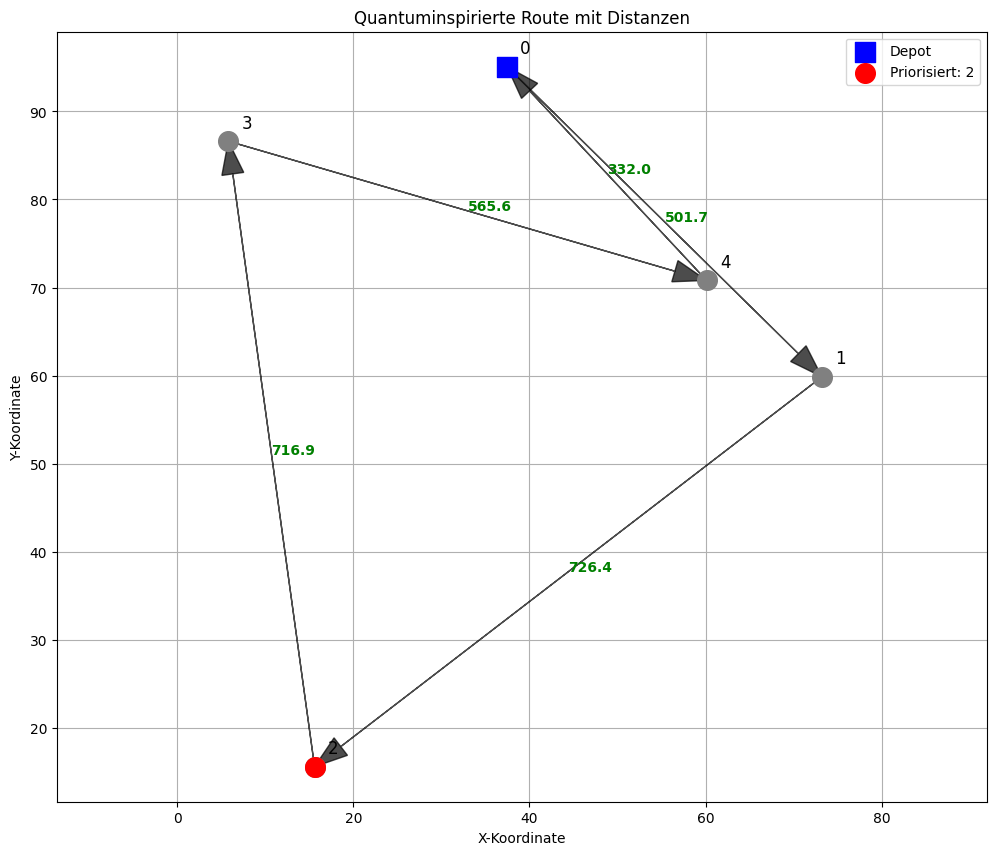

In [33]:
######## Zelle 7: Route plotten mit Distanzen ########

import matplotlib.pyplot as plt

x = coords[:, 0]
y = coords[:, 1]
route_array = np.array(route)

plt.figure(figsize=(12, 10))

# Punkte zeichnen
plt.scatter(x, y, c="gray", s=200, zorder=3)
plt.scatter(x[0], y[0], c="blue", s=200, marker="s", label="Depot", zorder=4)
plt.scatter(x[prioritized_idx], y[prioritized_idx], 
            c="red", s=200, marker="o", label=f"Priorisiert: {prioritized_idx}", zorder=4)

# Pfeile mit Distanzbeschriftung
for i in range(len(route_array) - 1):
    start = route_array[i]
    end = route_array[i+1]

    # Pfeil
    plt.arrow(x[start], y[start],
              x[end] - x[start],
              y[end] - y[start],
              head_width=2.5, length_includes_head=True, color="black", alpha=0.7, zorder=2)

    # Distanz berechnen (aus Matrix oder neu)
    dist = time_matrix[start, end]
    mid_x = (x[start] + x[end]) / 2
    mid_y = (y[start] + y[end]) / 2
    plt.text(mid_x, mid_y, f"{dist:.1f}", color="green", fontsize=10, weight="bold")

# Labels zu den Punkten
for idx in range(len(coords)):
    plt.text(x[idx] + 1.5, y[idx] + 1.5, str(idx), fontsize=12)

plt.title("Quantuminspirierte Route mit Distanzen")
plt.xlabel("X-Koordinate")
plt.ylabel("Y-Koordinate")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.savefig("quantum_route_plot.png", dpi=600, bbox_inches='tight')
plt.show()
